# Regresión lineal para predecir la progresión de la diabetes

Este notebook construye y evalúa un modelo de **regresión lineal** usando el conjunto de datos `Diabetes` incluido en `scikit-learn`. El objetivo es predecir la progresión de la enfermedad un año después de la evaluación inicial a partir de variables médicas normalizadas.

Variables disponibles:

- `age`: edad del paciente normalizada.
- `sex`: sexo del paciente codificado y normalizado.
- `bmi`: índice de masa corporal.
- `bp`: presión arterial promedio.
- `s1`: colesterol total.
- `s2`: LDL.
- `s3`: HDL.
- `s4`: relación colesterol total / HDL.
- `s5`: triglicéridos.
- `s6`: glucosa en ayuno.


## 1. Importación de librerías

Se importan las librerías necesarias para cargar datos, entrenar el modelo, evaluar resultados y generar gráficas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42


## 2. Carga y exploración inicial de datos

El dataset viene precargado en `scikit-learn`, por lo que no se descarga ningún archivo externo.


In [2]:
diabetes_data = load_diabetes()

X = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
y = pd.Series(diabetes_data.target, name='progresion')

df = X.copy()
df['progresion'] = y

print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print(f'Valores faltantes: {int(df.isna().sum().sum())}')
display(df.head())


Filas: 442
Columnas: 11
Valores faltantes: 0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progresion
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
resumen = df.describe().T.round(3)
display(resumen)


,count,mean,std,min,25%,50%,75%,max
age,442.0,-0.000,0.048,-0.107,-0.037,0.005,0.038,0.111
sex,442.0,0.000,0.048,-0.045,-0.045,-0.045,0.051,0.051
bmi,442.0,-0.000,0.048,-0.090,-0.034,-0.007,0.031,0.171
bp,442.0,-0.000,0.048,-0.112,-0.037,-0.006,0.036,0.132
s1,442.0,-0.000,0.048,-0.127,-0.034,-0.004,0.028,0.154
s2,442.0,0.000,0.048,-0.116,-0.030,-0.004,0.030,0.199
s3,442.0,-0.000,0.048,-0.102,-0.035,-0.007,0.029,0.181
s4,442.0,-0.000,0.048,-0.076,-0.039,-0.003,0.034,0.185
s5,442.0,0.000,0.048,-0.126,-0.033,-0.002,0.032,0.134
s6,442.0,0.000,0.048,-0.138,-0.033,-0.001,0.028,0.136


## 3. División de datos

Se separa el conjunto en entrenamiento y prueba. El modelo aprende con el 80% de los datos y se evalúa con el 20% restante.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f'Tamaño de entrenamiento: {X_train.shape[0]} registros')
print(f'Tamaño de prueba: {X_test.shape[0]} registros')


Tamaño de entrenamiento: 353 registros
Tamaño de prueba: 89 registros


## 4. Entrenamiento del modelo

Se utiliza `LinearRegression`, que busca una combinación lineal de las variables médicas para estimar la progresión de la diabetes.


In [5]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print('Modelo entrenado correctamente.')
print(f'Intercepto: {modelo.intercept_:.4f}')


Modelo entrenado correctamente.
Intercepto: 151.3456


## 5. Evaluación del modelo

Para medir el desempeño se calculan:

- **MAE**: error absoluto promedio.
- **MSE**: error cuadrático medio.
- **RMSE**: raíz del error cuadrático medio, expresado en las mismas unidades del objetivo.
- **R²**: proporción de variabilidad explicada por el modelo.


In [6]:
y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metricas = pd.DataFrame({
    'Métrica': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Valor': [mae, mse, rmse, r2]
})
metricas['Valor'] = metricas['Valor'].round(4)

display(metricas)
print(f'Evaluación final -> MAE: {mae:.2f} | MSE: {mse:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f}')


,Métrica,Valor
0,MAE,42.7941
1,MSE,2900.1936
2,RMSE,53.8534
3,R²,0.4526


Evaluación final -> MAE: 42.79 | MSE: 2900.19 | RMSE: 53.85 | R²: 0.4526


## 6. Importancia de las variables según los coeficientes

Los coeficientes muestran el efecto estimado de cada variable sobre la progresión. Como las variables están normalizadas, pueden compararse de forma más directa.


In [7]:
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})
coeficientes['Impacto absoluto'] = coeficientes['Coeficiente'].abs()
coeficientes = coeficientes.sort_values('Impacto absoluto', ascending=False)

display(coeficientes.round(4))


,Variable,Coeficiente,Impacto absoluto
4,s1,-931.4888,931.4888
8,s5,736.1989,736.1989
2,bmi,542.4288,542.4288
5,s2,518.0623,518.0623
3,bp,347.7038,347.7038
7,s4,275.3179,275.3179
1,sex,-241.9644,241.9644
6,s3,163.4200,163.4200
9,s6,48.6707,48.6707
0,age,37.9040,37.9040


## 7. Visualización de resultados

La primera gráfica compara valores reales contra predicciones. La segunda muestra los residuos, que son las diferencias entre el valor real y el valor estimado.


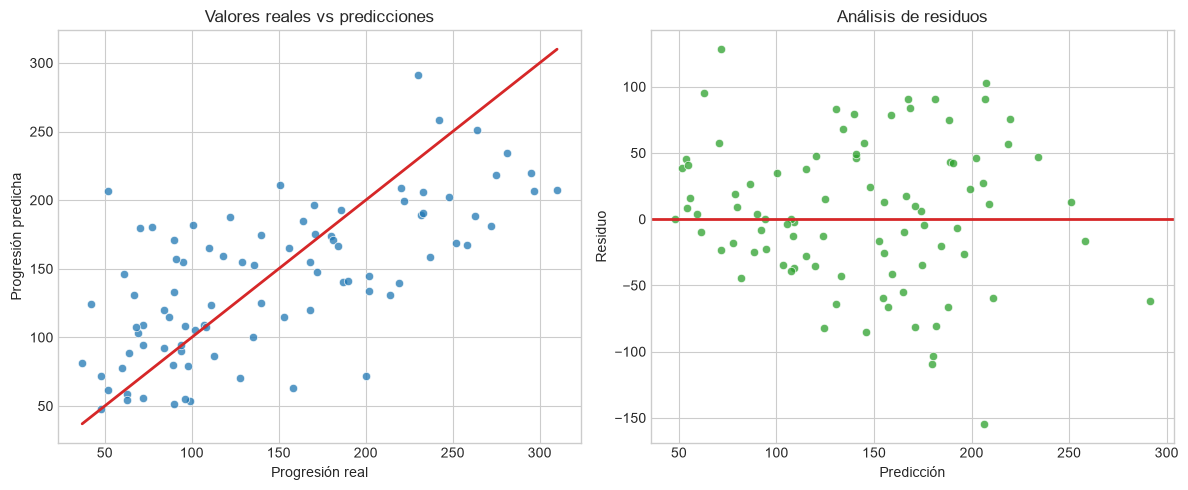

In [8]:
residuos = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred, alpha=0.75, color='#1f77b4', edgecolor='white', linewidth=0.6)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='#d62728', linewidth=2)
axes[0].set_title('Valores reales vs predicciones')
axes[0].set_xlabel('Progresión real')
axes[0].set_ylabel('Progresión predicha')

axes[1].scatter(y_pred, residuos, alpha=0.75, color='#2ca02c', edgecolor='white', linewidth=0.6)
axes[1].axhline(0, color='#d62728', linewidth=2)
axes[1].set_title('Análisis de residuos')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Residuo')

plt.tight_layout()
plt.show()


## 8. Captura de la evaluación final

La siguiente celda genera una imagen con las métricas finales del modelo. El archivo queda guardado como `evaluacion_final_modelo.png` para usarlo como evidencia de la evaluación.


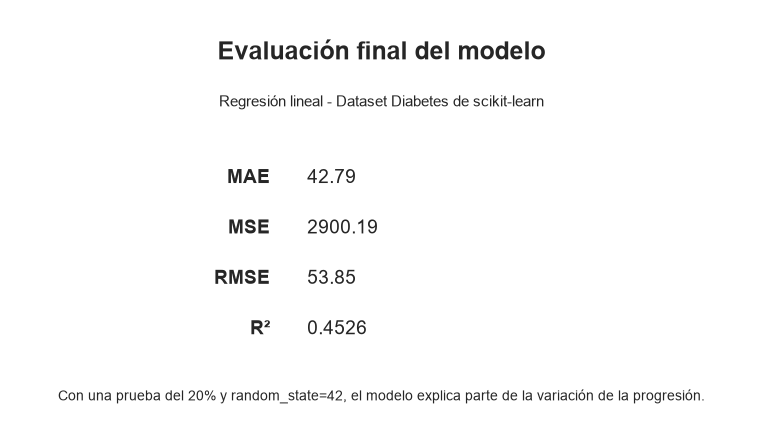

Imagen guardada: evaluacion_final_modelo.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axis('off')

ax.text(0.5, 0.90, 'Evaluación final del modelo', ha='center', va='center', fontsize=18, fontweight='bold')
ax.text(0.5, 0.78, 'Regresión lineal - Dataset Diabetes de scikit-learn', ha='center', va='center', fontsize=11)

metric_lines = [
    ('MAE', f'{mae:.2f}'),
    ('MSE', f'{mse:.2f}'),
    ('RMSE', f'{rmse:.2f}'),
    ('R²', f'{r2:.4f}')
]

for idx, (name, value) in enumerate(metric_lines):
    y_pos = 0.60 - idx * 0.12
    ax.text(0.35, y_pos, name, ha='right', va='center', fontsize=14, fontweight='bold')
    ax.text(0.40, y_pos, value, ha='left', va='center', fontsize=14)

ax.text(
    0.5,
    0.08,
    'Con una prueba del 20% y random_state=42, el modelo explica parte de la variación de la progresión.',
    ha='center',
    va='center',
    fontsize=10,
    wrap=True
)

plt.tight_layout()
fig.savefig('evaluacion_final_modelo.png', dpi=200, bbox_inches='tight')
plt.show()

print('Imagen guardada: evaluacion_final_modelo.png')


## 9. Conclusión

El modelo de regresión lineal permite estimar la progresión de la diabetes usando variables médicas normalizadas. En esta ejecución, el valor de **R²** indica que el modelo explica una parte moderada de la variabilidad de la progresión. Además, los coeficientes sugieren qué variables tienen mayor relación lineal con el resultado, aunque para una interpretación médica real sería necesario un análisis clínico más profundo.
